## Tutorial on how to use Casida code

In [1]:
from dftpy.functional.xc import XC
from dftpy.field import DirectField

In [2]:
pip list

Package                   Version
------------------------- ----------------------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
ase                       3.26.0
asttokens                 3.0.1
async-lru                 2.1.0
attrs                     25.4.0
babel                     2.17.0
beautifulsoup4            4.14.3
bleach                    6.3.0
CasidaPy                  0.1.0
certifi                   2026.1.4
cffi                      2.0.0
charset-normalizer        3.4.4
comm                      0.2.3
contourpy                 1.3.2
cycler                    0.12.1
debugpy                   1.8.19
decorator                 5.2.1
defusedxml                0.7.1
dftpy                     2.1.3.dev77+g3e14c9eeb
edftpy                    0.0.1.dev0
exceptiongroup            1.3.1
executing                 2.2.1
f90wrap                   0.2.16
fastjsonschema            2.21.2
fonttools        

In [3]:
from casidapy.casida_engine import CasidaKS_MPI, run_casida_in_memory
from casidapy.utils.casida_utils import normalize_wavefunctions
from casidapy.adapter.qepy import extract_casida_inputs_from_qepy_driver, slice_active_space
from casidapy.casida_api import CasidaOptions

--------------------------------------------------------------------------
No OpenFabrics connection schemes reported that they were able to be
used on a specific port.  As such, the openib BTL (OpenFabrics
support) will be disabled for this port.

  Local host:           amarel2
  Local device:         mlx5_0
  Local port:           1
  CPCs attempted:       rdmacm, udcm
--------------------------------------------------------------------------


In [4]:
import matplotlib.pyplot as plt

[amarel2.amarel.rutgers.edu:48560] 1 more process has sent help message help-mpi-btl-openib-cpc-base.txt / no cpcs for port
[amarel2.amarel.rutgers.edu:48560] Set MCA parameter "orte_base_help_aggregate" to 0 to see all help / error messages


In [5]:
try:
    from mpi4py import MPI
    comm=MPI.COMM_WORLD
except:
    comm=None

In [6]:
# comm

In [7]:
import numpy as np
#
from qepy.driver import Driver

In [8]:
qe_options = {
    '&control': {
        'calculation': "'scf'",
        'pseudo_dir': "'./'",
    },
    '&system': {
        'ibrav' : 0,
        'degauss': 0.005,
        'ecutwfc': 30,
        'nat': 1,
        'ntyp': 1,
        'occupations': "'smearing'",
    },
    'atomic_positions crystal': ['Al    0.0  0.0  0.0'],
    'atomic_species': ['Al  26.98 Al_ONCV_PBE-1.2.upf'],
    'k_points automatic': ['2 2 2 1 1 1'],
    'cell_parameters angstrom':[
        '0.     2.025  2.025',
        '2.025  0.     2.025',
        '2.025  2.025  0.   '],
}

In [9]:
driver = Driver(inputfile='qe.in', logfile=True) 
#driver = Driver(qe_options=qe_options, logfile=True) 

In [10]:
driver.scf()

-39.48761577950281

In [11]:
atoms = driver.get_ase_atoms()

In [12]:
atoms

Atoms(symbols='Al', pbc=False, cell=[[0.0, 2.025, 2.025], [2.025, 0.0, 2.025], [2.025, 2.025, 0.0]])

In [13]:
ions = driver.get_dftpy_ions()

# Option 1

In [ ]:
casida_inputs, casida_options = extract_casida_inputs_from_qepy_driver(driver,atoms, )

In [15]:
# casida_options, casida_inputs

In [16]:
# occs = casida_inputs.occs
# oc = int(sum(occs))
# ov = int(len(occs) - oc)
# print(oc,ov)

In [17]:
# casida_options = CasidaOptions(oc,ov,oc+ov,matrix_free=True)
# casida_options = CasidaOptions()

In [18]:
# casida_options

In [19]:
xc_func = XC(xc='PBE')
totalfunctional = xc_func

In [20]:
casida = CasidaKS_MPI(
        casida_inputs.rho_ks,
        totalfunctional,)

In [21]:
results = run_casida_in_memory(casida_inputs,casida_options)

Building Casida matrices: 1 occ x 5 unocc = 5 transitions
MPI ranks: 1 (CPU only)
  Rank 0: row 0/5
Matrix construction complete. C shape: (5, 5)


In [22]:
results.omega

array([0.49400553, 0.7670902 , 0.7684718 , 0.89358328, 0.89566781])

In [23]:
# casida.oscillator_strengths()

# Option 2

In [24]:
rho_ks = driver.get_density()

In [25]:
new_rho_ks = driver.data2field(rho_ks)

In [26]:
xc_func = XC(xc='PBE')
totalfunctional = xc_func

In [27]:
casida = CasidaKS_MPI(
        new_rho_ks,
        totalfunctional,)

In [28]:
occs = casida_inputs.occs
oc = int(sum(occs))
ov = int(len(occs) - oc)
len_orb = oc+ov
print(oc,ov)

1 5


In [29]:
psi_list = casida_inputs.psi
psi_list = [DirectField(grid=casida_inputs.grid, data=psi_list[i])
                for i in range(len(psi_list))]

psi_list = [psi / np.sqrt(ions.cell.volume) for psi in psi_list]


psi_list = normalize_wavefunctions(psi_list, casida_inputs.grid)

In [30]:
eigs = casida_inputs.eigs

In [31]:
occ_e, unocc_e, psi_occ, psi_unocc = slice_active_space(
        eigs, psi_list, oc, ov,
        n_total_occ=None,)

In [32]:
casida.set_active_orbitals(occ_e, unocc_e, psi_occ, psi_unocc)

In [33]:
casida.build_matrices(tda=False)

Building Casida matrices: 1 occ x 5 unocc = 5 transitions
MPI ranks: 1 (CPU only)
  Rank 0: row 0/5
Matrix construction complete. C shape: (5, 5)


(array([[ 4.94641943e-01,  1.42548422e-06,  1.73727538e-06,
          6.14370450e-03,  7.38712698e-06],
        [ 1.42548422e-06,  7.68197484e-01,  7.57609618e-04,
          2.25108059e-05, -4.00000128e-03],
        [ 1.73727538e-06,  7.57609618e-04,  7.68213158e-01,
         -1.24626926e-05, -1.45017789e-03],
        [ 6.14370450e-03,  2.25108059e-05, -1.24626926e-05,
          8.93808738e-01, -7.89811309e-06],
        [ 7.38712698e-06, -4.00000128e-03, -1.45017789e-03,
         -7.89811309e-06,  8.95596024e-01]]),
 array([[ 2.27425492e-02,  1.42548422e-06,  1.73727538e-06,
          6.14370450e-03,  7.38712698e-06],
        [ 1.42548422e-06,  2.31985741e-02,  7.57609618e-04,
          2.25108059e-05, -4.00000128e-03],
        [ 1.73727538e-06,  7.57609618e-04,  2.32134790e-02,
         -1.24626926e-05, -1.45017789e-03],
        [ 6.14370450e-03,  2.25108059e-05, -1.24626926e-05,
          2.26914185e-02, -7.89811309e-06],
        [ 7.38712698e-06, -4.00000128e-03, -1.45017789e-03,
  

In [34]:
omega, Z = casida.solve(k=25)

In [35]:
omega,Z

(array([0.49400553, 0.7670902 , 0.7684718 , 0.89358328, 0.89566781]),
 array([[ 9.99899028e-01,  4.35527941e-06,  7.46634656e-06,
         -1.42103191e-02, -3.83476505e-05],
        [-3.70738497e-06, -7.38803728e-01,  6.73225276e-01,
         -5.09823182e-05, -3.06068050e-02],
        [-6.89421754e-06,  6.73752598e-01,  7.38871523e-01,
          1.39931690e-04, -1.12378127e-02],
        [-1.42103605e-02,  1.90907836e-04, -4.44518119e-05,
         -9.99891329e-01, -3.91873779e-03],
        [-1.75433077e-05, -1.50482842e-02,  2.89240010e-02,
         -3.92095955e-03,  9.99460643e-01]]))

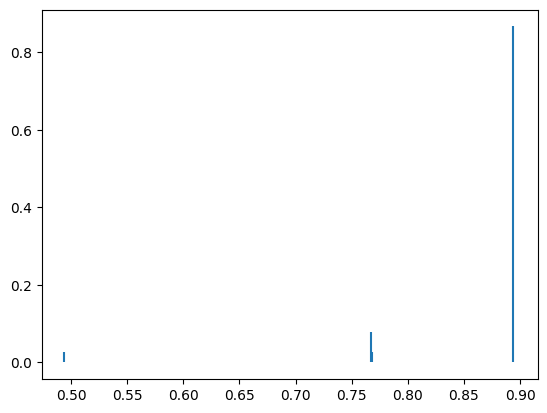

In [36]:
plt.vlines(omega,0,casida.oscillator_strengths(25))